In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -U wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 72.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: wandb
    Found existing installation: wandb 0.22.2
    Uninstalling wandb-0.22.2:
      Successfully uninstalled wandb-0.22.2


In [3]:
import wandb

In [4]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [5]:
import torch
import torchaudio
import torchaudio.transforms as T
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset, Audio
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from huggingface_hub import notebook_login

In [29]:
base = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
train_path = os.path.join(base , "genres_stems")
test = os.path.join(base , "mashups")

In [30]:
genres = sorted(os.listdir(train_path))
X_train =[]
y_train = [] 
def load_and_merge_stems(song_path):
    stems = []
    for stem in ["drums.wav", "vocals.wav" ,"bass.wav" , "other.wav"]:
        path = os.path.join(song_path , stem)
        y , sr = librosa.load(path, sr=22050)
        stems.append(y)
    merged = np.sum(stems , axis =0)
    return merged
    
print("Loading training data...")

for genre in genres :
    genre_path = os.path.join(train_path , genre)
    songs = os.listdir(genre_path)

    for song in songs[:50]:
        song_path = os.path.join(genre_path , song)
        audio = load_and_merge_stems(song_path)
        audio = librosa.util.fix_length(audio , size = 22050*5)
        mel = librosa.feature.melspectrogram(y=audio , sr = 22050 , n_mels = 128)
        mel_db= librosa.power_to_db(mel)

        X_train.append(mel_db)
        y_train.append(genre)

print("loaded")

Loading training data...
loaded


In [31]:
# Paths
DATA_ROOT  = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/mes'  # already set
TRAIN_PATH = train_path   # you already have this

# Config
SR          = 22050
DURATION    = 5
N_MELS      = 128
NUM_CLASSES = 10

GENRES    = sorted(['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock'])
GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
IDX2GENRE = {i: g for g, i in GENRE2IDX.items()}

print("Genres:", GENRES)
print("Mapping:", GENRE2IDX)

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Mapping: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [32]:
from sklearn.model_selection import train_test_split

# You already have X_train and y_train from your previous code
# Just convert genre strings to integers
y_train_idx = [GENRE2IDX[g] for g in y_train]

X = np.array(X_train)        # (N, 128, frames)
y = np.array(y_train_idx)    # (N,)

print(f"Total samples: {len(X)}")
print(f"Spectrogram shape: {X[0].shape}")
print(f"Unique labels: {np.unique(y)}")

Total samples: 500
Spectrogram shape: (128, 216)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [33]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reuse your already loaded data
X = np.array(X_train)          # (100, 128, 216)
y = np.array([GENRE2IDX[g] for g in y_train])

# Train / Val split
split = X.shape[0]
train_X, val_X, train_y, val_y = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(train_X)}  |  Val: {len(val_X)}')

# Dataset class
class MelDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, 128, 216)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'mel_spectrogram': self.X[idx], 'label': self.y[idx]}

train_ds = MelDataset(train_X, train_y)
val_ds   = MelDataset(val_X,   val_y)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

# Sanity check
sample = next(iter(train_loader))
print(f"Batch shape : {sample['mel_spectrogram'].shape}")  # (16, 1, 128, 216)
print(f"Labels      : {sample['label']}")

Train: 400  |  Val: 100
Batch shape : torch.Size([16, 1, 128, 216])
Labels      : tensor([2, 8, 1, 2, 1, 9, 2, 6, 2, 6, 1, 5, 2, 2, 7, 1])


In [34]:
NUM_CLASSES = 10

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # After 2x pooling:
        # Mel bins  : 128 / 4 = 32
        # Time frames: 216 / 4 = 54
        self.fc1     = nn.Linear(32 * 32 * 54, 128)
        self.fc2     = nn.Linear(128, NUM_CLASSES)  # 10 genres
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x shape: (batch, 1, 128, 216)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)           # Flatten
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

cnn_model = SimpleCNN()
print(cnn_model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=55296, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


Training on device: cuda

Starting Simple CNN Training...


Epoch 1/15 | Loss: 6.8388 | Val Acc: 0.2400 | Val Macro F1: 0.2146
Epoch 2/15 | Loss: 2.1147 | Val Acc: 0.2600 | Val Macro F1: 0.1374
Epoch 3/15 | Loss: 2.0440 | Val Acc: 0.2700 | Val Macro F1: 0.1517
Epoch 4/15 | Loss: 1.9905 | Val Acc: 0.2700 | Val Macro F1: 0.1828
Epoch 5/15 | Loss: 2.0166 | Val Acc: 0.3000 | Val Macro F1: 0.1833
Epoch 6/15 | Loss: 1.9685 | Val Acc: 0.2900 | Val Macro F1: 0.1601
Epoch 7/15 | Loss: 1.9064 | Val Acc: 0.3300 | Val Macro F1: 0.1939
Epoch 8/15 | Loss: 1.8790 | Val Acc: 0.3300 | Val Macro F1: 0.2064
Epoch 9/15 | Loss: 1.7990 | Val Acc: 0.3200 | Val Macro F1: 0.2042
Epoch 10/15 | Loss: 1.7453 | Val Acc: 0.3300 | Val Macro F1: 0.1989
Epoch 11/15 | Loss: 1.7415 | Val Acc: 0.2800 | Val Macro F1: 0.1852
Epoch 12/15 | Loss: 1.7371 | Val Acc: 0.3200 | Val Macro F1: 0.2095
Epoch 13/15 | Loss: 1.7121 | Val Acc: 0.3500 | Val Macro F1: 0.2376
Epoch 14/15 | Loss: 1.6179 | Val Acc: 0.3700 | Val Macro F1: 0.2628
Epoch 15/15 | Loss: 1.6603 | Val Acc: 0.3500 | Val Macro 

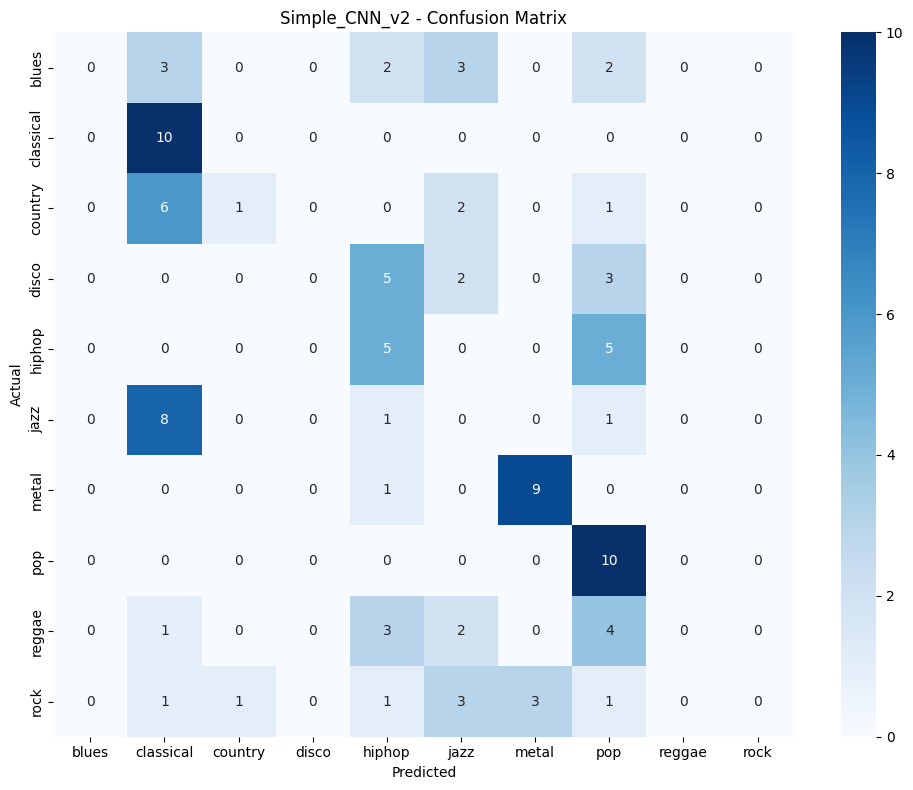

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_loss,█▂▂▁▂▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▂▃▃▄▄▆▆▅▆▃▅▇█▇
val_macro_f1,▅▁▂▄▄▂▄▅▅▄▄▅▇█▇
epoch,15
train_loss,1.66032
val_accuracy,0.35
val_macro_f1,0.23954


In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on device: {device}')

def train_eval_model(model, run_name, t_loader, v_loader, epochs=5, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Initialize W&B Run
    wandb.init(project='DL_GENAI_Audio', name=run_name,
               config={'lr': lr, 'epochs': epochs, 'num_classes': NUM_CLASSES})

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch in t_loader:
            inputs = batch['mel_spectrogram'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation Phase
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in v_loader:
                inputs = batch['mel_spectrogram'].to(device)
                labels = batch['label'].to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc    = accuracy_score(all_labels, all_preds)
        mac_f1 = f1_score(all_labels, all_preds, average='macro')

        print(f'Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(t_loader):.4f} | Val Acc: {acc:.4f} | Val Macro F1: {mac_f1:.4f}')

        # Log to W&B
        wandb.log({'epoch': epoch+1,
                   'train_loss': train_loss/len(t_loader),
                   'val_accuracy': acc,
                   'val_macro_f1': mac_f1})

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES)
    plt.title(f'{run_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    wandb.finish()
    return model

print('\nStarting Simple CNN Training...')
cnn_model = train_eval_model(cnn_model, 'Simple_CNN_v2', train_loader, val_loader, epochs=15 , lr=0.0001)

In [37]:
import pandas as pd

# ── Update this path with your correct path from above ──
SUB_PATH  = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv'
TEST_PATH = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv'

sub = pd.read_csv(SUB_PATH)
print(f'Test samples: {len(sub)}')
print(sub.head())

# Load & predict each test mashup
cnn_model.eval()
predictions = []

for test_id in sub['id']:
    test_file = os.path.join(TEST_PATH, f'{test_id}.wav')
    try:
        # Load audio
        audio, sr = librosa.load(test_file, sr=22050)
        audio = librosa.util.fix_length(audio, size=22050 * 5)

        # Mel spectrogram
        mel    = librosa.feature.melspectrogram(y=audio, sr=22050, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)

        # Convert to tensor → (1, 1, 128, 216)
        tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        # Predict
        with torch.no_grad():
            output = cnn_model(tensor)
            _, pred = torch.max(output, 1)

        predictions.append(IDX2GENRE[pred.item()])

    except Exception as e:
        print(f'Error on {test_id}: {e}')
        predictions.append('jazz')   # fallback

sub['genre'] = predictions
sub.to_csv('submission.csv', index=False)
print('\nsubmission.csv saved!')
print(sub['genre'].value_counts())

Test samples: 3020
   id      genre
0   1       jazz
1   2      blues
2   3  classical
3   4        pop
4   5      disco
Error on 1: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/1.wav'
Error on 2: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2.wav'
Error on 3: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/3.wav'
Error on 4: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/4.wav'
Error on 5: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/5.wav'
Error on 6: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/6.wav'
Error on 7: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/7.wav'
Error on 8: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.cs

/tmp/ipykernel_55/2061934085.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(test_file, sr=22050)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error on 2464: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2464.wav'
Error on 2465: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2465.wav'
Error on 2466: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2466.wav'
Error on 2467: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2467.wav'
Error on 2468: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2468.wav'
Error on 2469: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2469.wav'
Error on 2470: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2470.wav'
Error on 2471: [Errno 20] Not a directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv/2471.wav'
Error on 2472: [Errno 20] Not a directory: '/kaggle/input/jan-20

In [33]:
"""model.load_state_dict(torch.load("/kaggle/working/best_ast_model.pth", map_location=DEVICE))
model.eval()
print("Best trained model loaded")"""

Best trained model loaded


In [34]:
"""def get_test_filename(test_id):
    return f"song{int(test_id):04d}.wav"

def predict_one_file(model, audio):
    audio = fix_length_center(audio)
    audio = normalize(audio)

    inputs = feature_extractor(
        audio,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt"
    )

    input_values = inputs["input_values"].to(DEVICE)

    with torch.no_grad():
        outputs = model(input_values=input_values)
        pred = torch.argmax(outputs.logits, dim=1).item()

    return pred

print("Prediction helper ready")"""

Prediction helper ready


In [35]:
"""test_df = pd.read_csv(TEST_CSV)
print("Test samples:", len(test_df))
print(test_df.head())

predictions = []

for test_id in tqdm(test_df["id"].values, total=len(test_df), desc="Predicting test files"):
    filename = get_test_filename(test_id)
    path = os.path.join(TEST_PATH, filename)

    try:
        audio = load_audio(path)
        pred_id = predict_one_file(model, audio)
        predictions.append(id2label[pred_id])
    except Exception as e:
        print(f"Error on {test_id}: {e}")
        predictions.append("jazz")

test_df["genre"] = predictions
test_df[["id", "genre"]].to_csv("/kaggle/working/submission.csv", index=False)

print("\nsubmission.csv saved!")
print(test_df["genre"].value_counts())
print(test_df.head())"""

Test samples: 3020
   id              filename
0   1  mashups/song0001.wav
1   2  mashups/song0002.wav
2   3  mashups/song0003.wav
3   4  mashups/song0004.wav
4   5  mashups/song0005.wav


Predicting test files:   0%|          | 0/3020 [00:00<?, ?it/s]


submission.csv saved!
genre
pop          447
hiphop       409
rock         390
metal        358
reggae       326
jazz         316
blues        227
disco        226
classical    165
country      156
Name: count, dtype: int64
   id              filename      genre
0   1  mashups/song0001.wav        pop
1   2  mashups/song0002.wav  classical
2   3  mashups/song0003.wav      disco
3   4  mashups/song0004.wav      metal
4   5  mashups/song0005.wav    country


In [36]:
"""sub = pd.read_csv("/kaggle/working/submission.csv")
print(sub.shape)
print(sub.head())"""

(3020, 2)
   id      genre
0   1        pop
1   2  classical
2   3      disco
3   4      metal
4   5    country


In [8]:
"""genres = sorted(os.listdir(train_path))
X_train =[]
y_train = [] 
def load_and_merge_stems(song_path):
    stems = []
    for stem in ["drums.wav", "vocals.wav" ,"bass.wav" , "other.wav"]:
        path = os.path.join(song_path , stem)
        y , sr = librosa.load(path, sr=22050)
        stems.append(y)
    merged = np.sum(stems , axis =0)
    return merged
    
print("Loading training data...")

for genre in genres :
    genre_path = os.path.join(train_path , genre)
    songs = os.listdir(genre_path)
    i=0
    for song in songs[:50]:
        print(i)
        song_path = os.path.join(genre_path , song)
        audio = load_and_merge_stems(song_path)
        audio = librosa.util.fix_length(audio , size = 22050*5)
        mel = librosa.feature.melspectrogram(y=audio , sr = 22050 , n_mels = 128)
        mel_db= librosa.power_to_db(mel)

        X_train.append(mel_db)
        y_train.append(genre)
        i = i+1

print("loaded")"""

Loading training data...
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
4

In [9]:
"""DATA_ROOT  = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/mes'  # already set
TRAIN_PATH = train_path   # you already have this

# Config
SR          = 22050
DURATION    = 5
N_MELS      = 128
NUM_CLASSES = 10

GENRES    = sorted(['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock'])
GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
IDX2GENRE = {i: g for g, i in GENRE2IDX.items()}

print("Genres:", GENRES)
print("Mapping:", GENRE2IDX)"""

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Mapping: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [10]:
"""from sklearn.model_selection import train_test_split

# You already have X_train and y_train from your previous code
# Just convert genre strings to integers
y_train_idx = [GENRE2IDX[g] for g in y_train]

X = np.array(X_train)        # (N, 128, frames)
y = np.array(y_train_idx)    # (N,)

print(f"Total samples: {len(X)}")
print(f"Spectrogram shape: {X[0].shape}")
print(f"Unique labels: {np.unique(y)}")"""

Total samples: 500
Spectrogram shape: (128, 216)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [11]:
"""from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reuse your already loaded data
X = np.array(X_train)          # (100, 128, 216)
y = np.array([GENRE2IDX[g] for g in y_train])

# Train / Val split
split = X.shape[0]
train_X, val_X, train_y, val_y = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(train_X)}  |  Val: {len(val_X)}')

# Dataset class
class MelDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, 128, 216)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'mel_spectrogram': self.X[idx], 'label': self.y[idx]}

train_ds = MelDataset(train_X, train_y)
val_ds   = MelDataset(val_X,   val_y)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

# Sanity check
sample = next(iter(train_loader))
print(f"Batch shape : {sample['mel_spectrogram'].shape}")  # (16, 1, 128, 216)
print(f"Labels      : {sample['label']}")"""

Train: 400  |  Val: 100
Batch shape : torch.Size([16, 1, 128, 216])
Labels      : tensor([3, 7, 6, 9, 5, 5, 6, 6, 5, 6, 1, 4, 5, 7, 6, 3])


In [12]:
"""NUM_CLASSES = 10

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # After 2x pooling:
        # Mel bins  : 128 / 4 = 32
        # Time frames: 216 / 4 = 54
        self.fc1     = nn.Linear(32 * 32 * 54, 128)
        self.fc2     = nn.Linear(128, NUM_CLASSES)  # 10 genres
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x shape: (batch, 1, 128, 216)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)           # Flatten
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

cnn_model = SimpleCNN()
print(cnn_model)"""

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=55296, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [19]:
"""import pandas as pd
import os
from tqdm.notebook import tqdm

SUB_PATH  = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv'
TEST_PATH = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups'

sub = pd.read_csv(SUB_PATH)

print(f'Test samples: {len(sub)}')
print(sub.head())

cnn_model = cnn_model.to(device)
cnn_model.eval()
predictions = []

for test_id in tqdm(sub['id'].values, total=len(sub), desc="Processing audio"):

    test_file = os.path.join(TEST_PATH, f'song{test_id:04d}.wav')
    
    try:
        # Load audio
        audio, sr = librosa.load(test_file, sr=22050)
        audio = librosa.util.fix_length(audio, size=22050 * 5)

        # Mel spectrogram
        mel    = librosa.feature.melspectrogram(y=audio, sr=22050, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)

        # Convert to tensor → (1, 1, 128, 216)
        tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        # Predict
        with torch.no_grad():
            output = cnn_model(tensor)
            _, pred = torch.max(output, 1)

        predictions.append(IDX2GENRE[pred.item()])

    except Exception as e:
        print(f'Error on {test_id}: {e}')
        predictions.append('jazz')   # fallback


sub['genre'] = predictions
sub.to_csv('submission.csv', index=False)

print('\nsubmission.csv saved!')
print(sub['genre'].value_counts())"""

Test samples: 3020
   id      genre
0   1       jazz
1   2      blues
2   3  classical
3   4        pop
4   5      disco


Processing audio:   0%|          | 0/3020 [00:00<?, ?it/s]


submission.csv saved!
genre
blues        864
hiphop       814
rock         674
country      633
classical     31
reggae         2
metal          1
jazz           1
Name: count, dtype: int64


In [23]:
"""device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on device: {device}')

def train_eval_model(model, run_name, t_loader, v_loader, epochs=5, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Initialize W&B Run
    wandb.init(project='DL_GENAI_Audio', name=run_name,
               config={'lr': lr, 'epochs': epochs, 'num_classes': NUM_CLASSES})

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch in t_loader:
            inputs = batch['mel_spectrogram'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation Phase
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in v_loader:
                inputs = batch['mel_spectrogram'].to(device)
                labels = batch['label'].to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc    = accuracy_score(all_labels, all_preds)
        mac_f1 = f1_score(all_labels, all_preds, average='macro')

        print(f'Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(t_loader):.4f} | Val Acc: {acc:.4f} | Val Macro F1: {mac_f1:.4f}')

        # Log to W&B
        wandb.log({'epoch': epoch+1,
                   'train_loss': train_loss/len(t_loader),
                   'val_accuracy': acc,
                   'val_macro_f1': mac_f1})

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES)
    plt.title(f'{run_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    wandb.finish()
    return model

print('\nStarting Simple CNN Training...')
cnn_model = train_eval_model(cnn_model, 'Simple_CNN_v2', train_loader, val_loader, epochs=15 , lr=0.0001)"""

Training on device: cpu

Starting Simple CNN Training...


KeyboardInterrupt: 

In [ ]:
"""label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)

X_train = np.array(X_train)
X_train = X_train[: , None , : , :]

X_train = torch.tensor(X_train , dtype=torch.float32)
y_train = torch.tensor(y_train , dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train , y_train)
train_loader = DataLoader(train_dataset , batch_size = 8 , shuffle=True)
"""

In [ ]:
"""
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''
# --- 4. Evaluation ---

# Predict on validation set
y_pred = clf.predict(X_val)

# Compute Macro F1 Score
macro_f1 = f1_score(y_val, y_pred, average='macro')

# Compute Confusion Matrix
cm = confusion_matrix(y_val, y_pred, labels=GENRES)

# Compute Classification Report
cr = classification_report(y_val, y_pred, target_names=GENRES)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''
# --- 5. Confusion Matrix Visualization ---

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# --- 6. Compute TP, TN, FP, FN for each genre ---

print("\nTP, TN, FP, FN per Genre:\n")

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    
    print(f"{genre.upper()}:")
    print(f"TP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}\n")"""

In [ ]:
data = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv")
data.to_csv("submission.csv" , index = False)

In [ ]:

# --- 4. Visualization & Metrics Extraction ---


In [ ]:
"""

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''
# --- 3. Model Training (Decision Tree) Continued ---

# COMPUTE PREDICTED VALUES
y_pred = clf.predict(X_val)

# COMPUTE VALIDATION MACRO F1 SCORE
macro_f1 = f1_score(y_val, y_pred, average='macro')

# COMPUTE CONFUSION MATRIX
cm = confusion_matrix(y_val, y_pred, labels=GENRES)

# COMPUTE CLASSIFICATION REPORT
cr = classification_report(y_val, y_pred, target_names=GENRES)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)


print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''

# Visualize the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Genre Classification')
plt.show()

# Compute TP, TN, FP, FN for all genres
print("\nPer-Genre Metrics (TP, TN, FP, FN):")
print("-" * 40)

for i, genre in enumerate(GENRES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)
    
    print(f"Genre: {genre}")
    print(f"  TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")"""